In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.signal import find_peaks
from tqdm import tqdm
from itertools import product
from joblib import Parallel, delayed
from matplotlib import rcParams
import seaborn as sns
from scipy.interpolate import griddata
import os
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks
# Пути к файлам
results_directory = "results"
summary_file_path = os.path.join(results_directory, "simulations_summary.csv")
    
if not os.path.exists(summary_file_path):
    print(f"Файл {summary_file_path} не найден!")
    
summary_tab = pd.read_csv(summary_file_path)
#summary_tab = summary_tab[(summary_tab['df']>0) & (summary_tab['df']<6.2)].copy(deep=True)
print(f"Загружено {len(summary_tab)} записей из сводной таблицы")
summary_tab.info()

Загружено 700 записей из сводной таблицы
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            700 non-null    object 
 1   A             700 non-null    float64
 2   df            700 non-null    float64
 3   w             700 non-null    float64
 4   results_file  700 non-null    object 
dtypes: float64(3), object(2)
memory usage: 27.5+ KB


In [2]:
summary_tab.head()

,id,A,df,w,results_file
0,366afeff-467e-4154-91db-360027af69e8,0.1,0.1,0.700004,sim_366afeff-467e-4154-91db-360027af69e8.npz
1,2a9f8474-472a-4814-978d-1c92154f1117,0.1,0.1,1.788900,sim_2a9f8474-472a-4814-978d-1c92154f1117.npz
2,2d5dea38-1000-409f-bb29-62b61523ea90,0.1,0.1,2.877796,sim_2d5dea38-1000-409f-bb29-62b61523ea90.npz
3,322f8e09-70b9-4fec-a099-60dd5d2d2dfc,0.1,0.1,3.966692,sim_322f8e09-70b9-4fec-a099-60dd5d2d2dfc.npz
4,b7d50eba-52c7-4730-a8fa-3784c346e580,0.1,0.1,5.055587,sim_b7d50eba-52c7-4730-a8fa-3784c346e580.npz


In [3]:
# Уникальные значения разностей фазы
DF = summary_tab['df'].unique()
print('Разности фазы(rad):', DF)

# Уникальные значения частот возбуждающего сигнала
Freqs = summary_tab['w'].unique()
print('Частоты(Hz):', Freqs)

# Уникальные значения амплитуд
Ampls = summary_tab['A'].unique()
print('Амплитуды(N):', Ampls)

# Значения duty для управляющего меандра
#Duty = summary_tab['duty'].unique()
#print('duty(%):', Duty)

Разности фазы(rad): [0.1        0.77590948 1.45181896 2.12772844 2.80363791 3.47954739
 4.15545687 4.83136635 5.50727583 6.18318531]
Частоты(Hz): [ 0.70000441  1.78890016  2.8777959   3.96669165  5.0555874   6.14448315
  7.23337889  8.32227464  9.41117039 10.50006614]
Амплитуды(N): [0.1        0.13333333 0.16666667 0.2        0.23333333 0.26666667
 0.3       ]


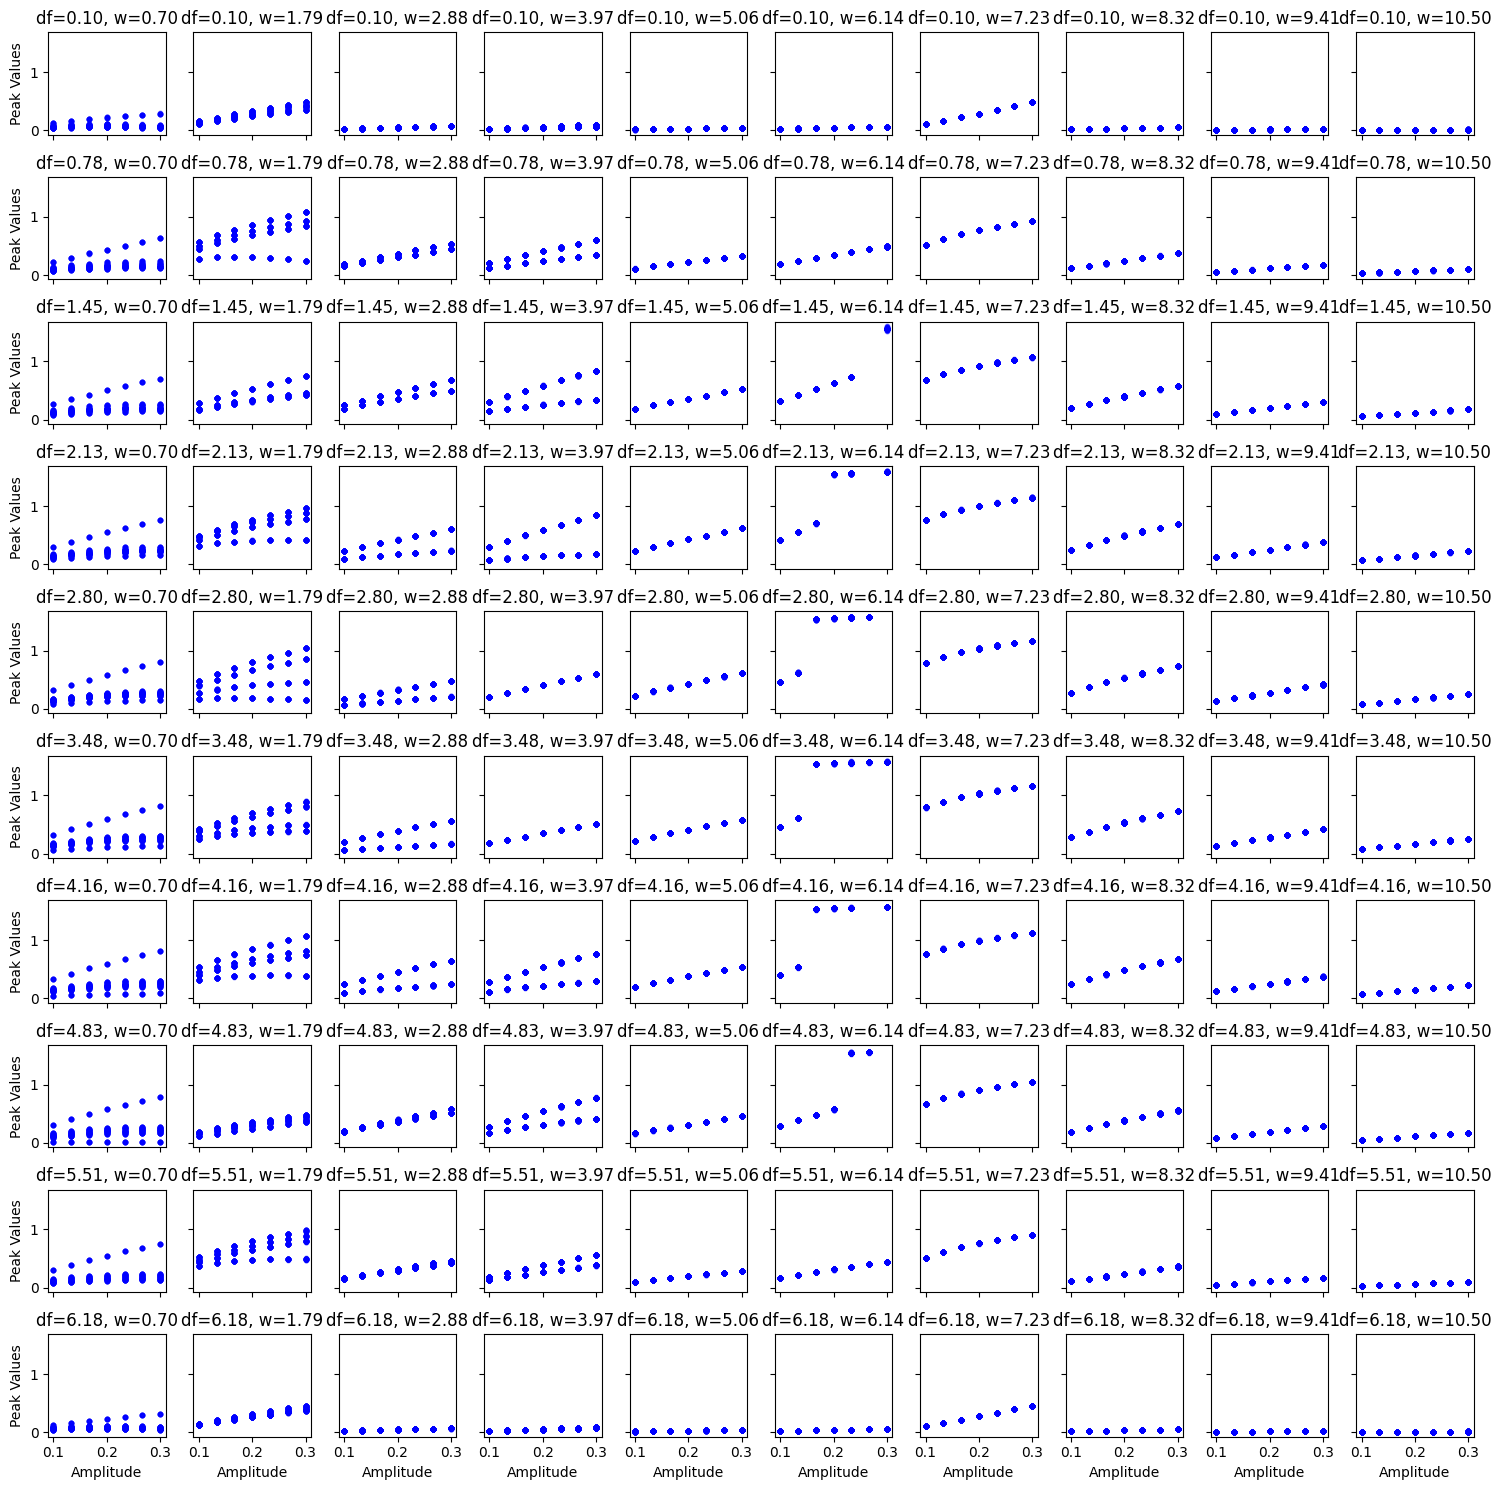

In [6]:
os.makedirs('Bifurcation', exist_ok=True)

def plot_faceted_peak_diagram(summary_tab, results_dir="results"):
    fig, axes = plt.subplots(len(DF), len(Freqs), figsize=(15, 15), sharex=True, sharey=True)
    
    if len(DF) == 1 or len(Freqs) == 1:
        axes = np.array(axes).reshape(len(DF), len(Freqs))
    
    for i, df in enumerate(DF):
        for j, freq in enumerate(Freqs):
            fixed_tab = summary_tab[(summary_tab['df'] == df) & (summary_tab['w'] == freq)]
            
            for _, row in fixed_tab.iterrows():
                data = np.load(os.path.join(results_dir, row['results_file']))
                Q = data['Q']
                T = data['T']
                
                mask = T > 15 * 1000
                Q = Q[mask]-np.pi/2
                T = T[mask]
                
                peaks, _ = find_peaks(Q, height=0)
                q_peaks = Q[peaks]
                ejections = np.where(q_peaks<np.pi*2)
                q_peaks=q_peaks[ejections]
                axes[i, j].scatter([row['A']] * len(q_peaks), q_peaks,
                                 c='blue', alpha=0.5, s=10)
            
            axes[i, j].set_title(f'df={df:.2f}, w={freq:.2f}')
            if i == len(DF) - 1:
                axes[i, j].set_xlabel('Amplitude')
            if j == 0:
                axes[i, j].set_ylabel('Peak Values')
    
    plt.tight_layout()
    plt.show()
    return fig

fig = plot_faceted_peak_diagram(summary_tab, results_dir="results")

Построение бифуркационных диаграмм для A=0.1


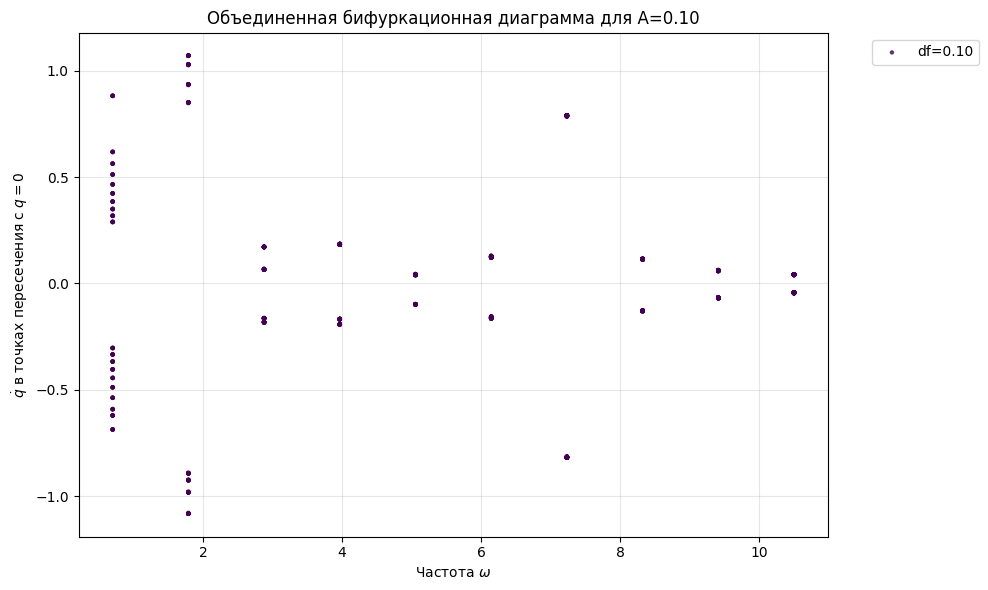

Построение бифуркационных диаграмм для A=0.1333333333333333


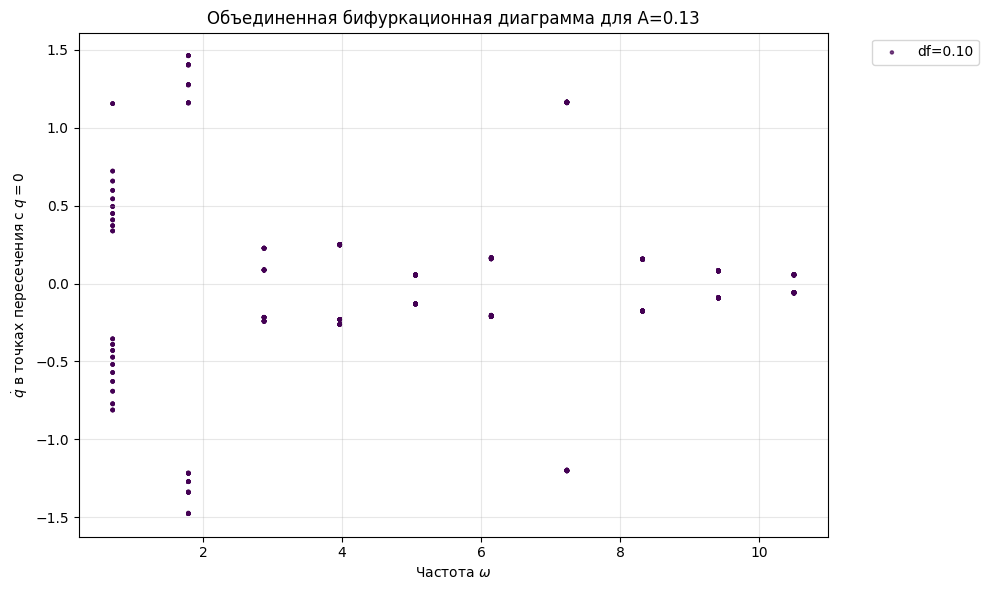

Построение бифуркационных диаграмм для A=0.1666666666666666


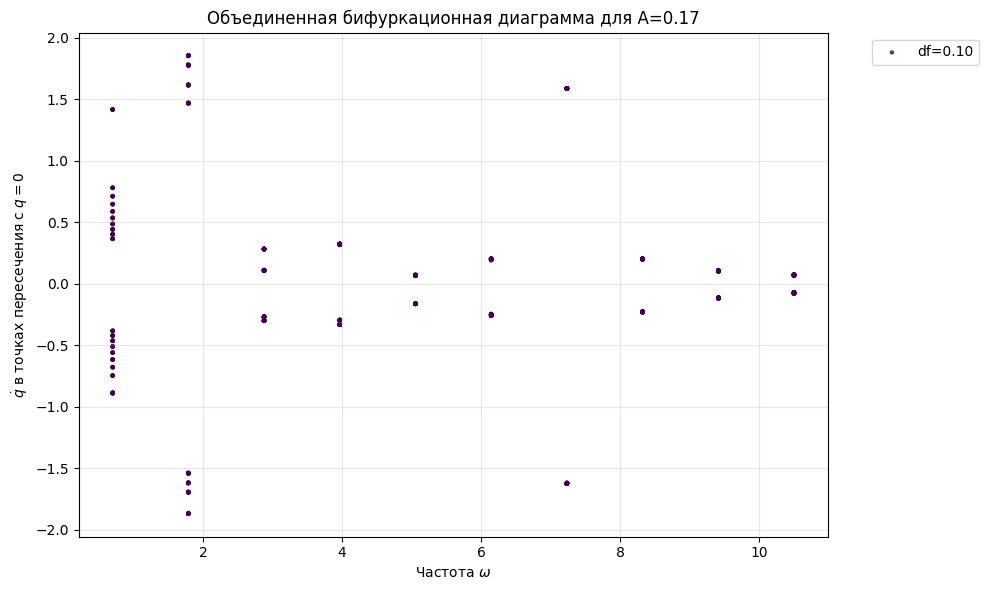

Построение бифуркационных диаграмм для A=0.2


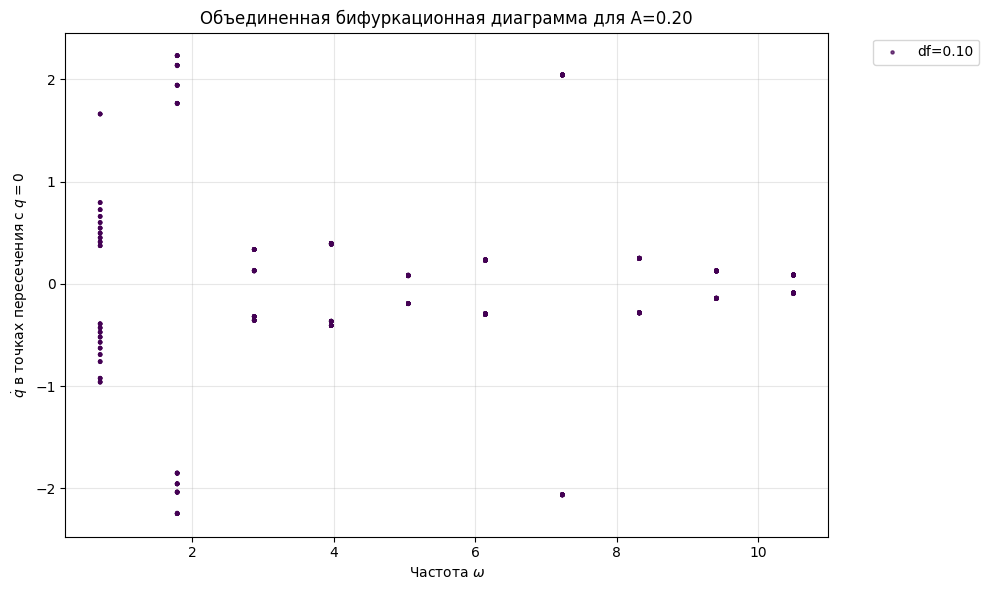

Построение бифуркационных диаграмм для A=0.2333333333333333


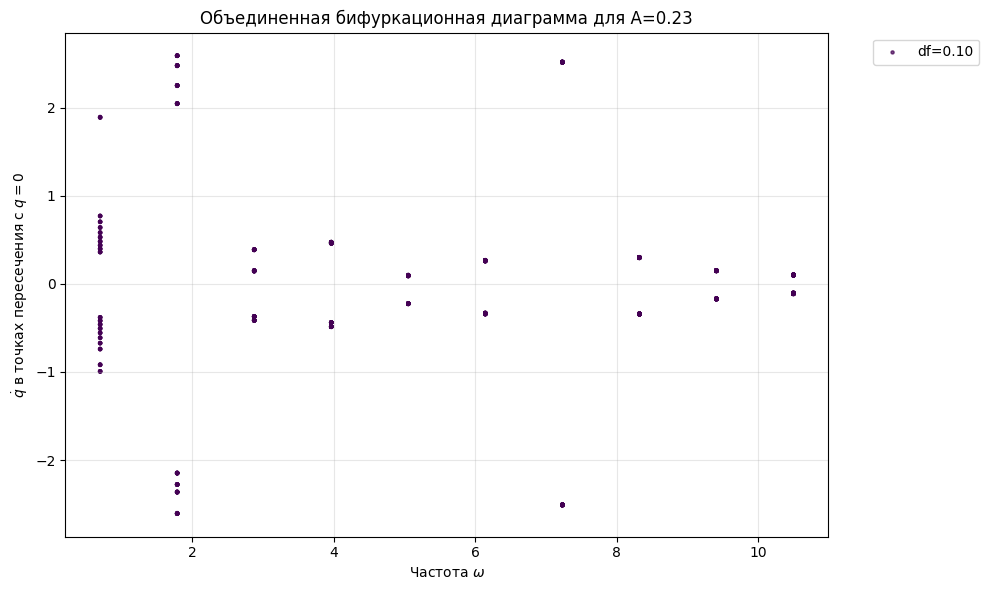

Построение бифуркационных диаграмм для A=0.2666666666666666


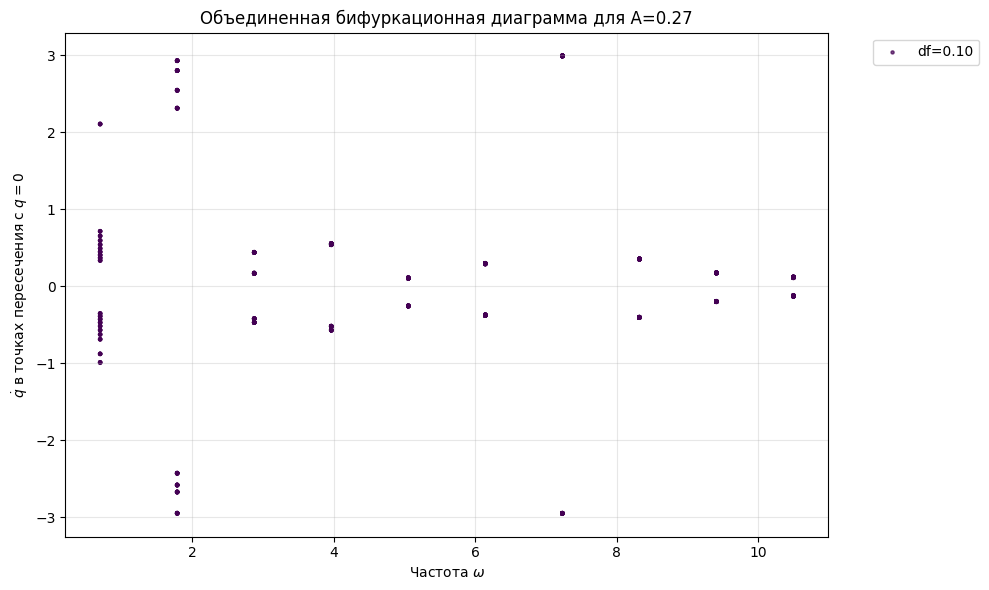

Построение бифуркационных диаграмм для A=0.3


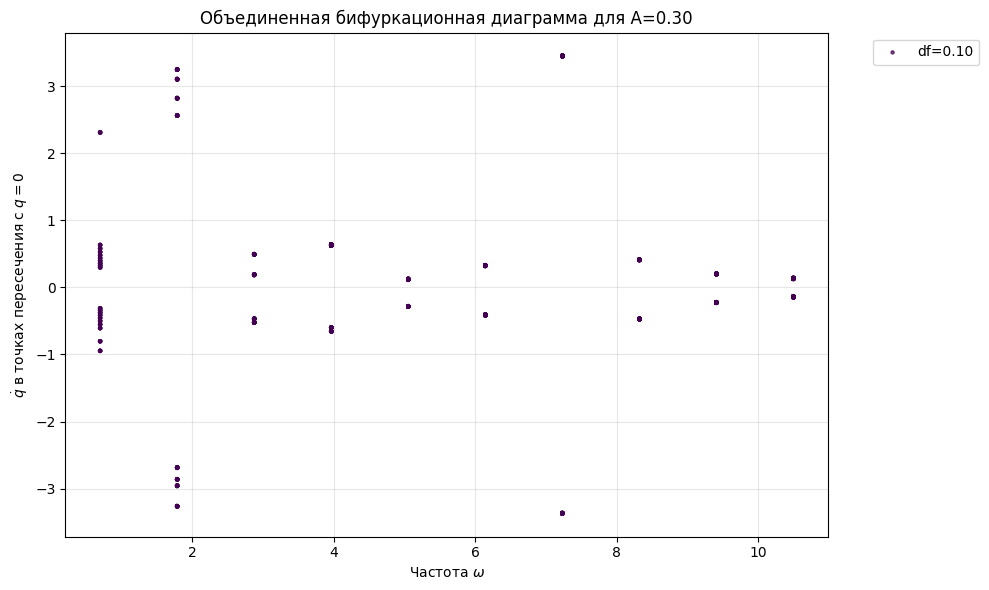

In [13]:
# Альтернативный вариант: объединенная бифуркационная диаграмма
def plot_combined_bifurcation(summary_tab, A, results_dir="results"):
    """
    Объединенная бифуркационная диаграмма на одном графике
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    fixed_A_tab = summary_tab[summary_tab['A'] == A]
    
    # Цвета для разных df
    colors = plt.cm.viridis(np.linspace(0, 1, len(DF)))
    
    for i, df in enumerate(DF[0:2:2]):
        all_freqs = []
        all_crossing_W = []
        
        for j, freq in enumerate(Freqs):
            row = fixed_A_tab[(fixed_A_tab['df'] == df) & (fixed_A_tab['w'] == freq)].iloc[0]
            data = np.load(os.path.join(results_dir, row['results_file']))
            
            T = data['T']
            mask = T > 50 * 1000
            Q = data['Q'][mask] - np.pi/2
            W = data['W'][mask]
            
            # Находим точки пересечения с осью q=0
            zero_crossings = np.where(np.diff(np.sign(Q)))[0]
            
            if len(zero_crossings) > 0:
                crossing_W = W[zero_crossings]
                all_freqs.extend([freq] * len(crossing_W))
                all_crossing_W.extend(crossing_W)
        
        # Рисуем точки для данного df
        if len(all_freqs) > 0:
            ax.scatter(all_freqs, all_crossing_W, c=[colors[i]] * len(all_freqs), 
                      s=20, alpha=0.7, marker='.', label=f'df={df:.2f}')
    
    ax.set_xlabel(r'Частота $\omega$')
    ax.set_ylabel(r'$\dot{q}$ в точках пересечения с $q=0$')
    ax.set_title(f'Объединенная бифуркационная диаграмма для A={A:.2f}')
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.savefig(f"Bifurcation/combined_bifurcation_A_{A:.2f}.png", dpi=300, bbox_inches='tight')
    plt.show()
    return fig

# Использование всех функций
for A in Ampls:
    print(f"Построение бифуркационных диаграмм для A={A}")
    
    # Объединенная версия
    plot_combined_bifurcation(summary_tab, A, results_dir="results")
